In [199]:
!pip install stable-baselines3[extra]

In [200]:
import platform
import torch
import math
import sys
import os
import random
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from abc import ABC
import numpy as np
import random
import tkinter as tk
import tkinter.font as tf
import copy
from itertools import combinations
from tqdm import tqdm


In [201]:
# Add the path to kaggle_datasets
sys.path.append(kaggle_datasets_path)

print(sys.path)

['/kaggle/working', '/kaggle/lib/kagglegym', '/kaggle/lib', '/usr/lib/python311.zip', '/usr/lib/python3.11', '/usr/lib/python3.11/lib-dynload', '/usr/local/lib/python3.11/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.11/dist-packages/IPython/extensions', '/usr/local/lib/python3.11/dist-packages/setuptools/_vendor', '/root/.ipython', '/kaggle/input/bioinformatics-project-dataset/', '/tmp/tmp311p7e62', '/kaggle/input/bioinformatics-project-dataset/', '/kaggle/input/bioinformatics-project-dataset/', '/kaggle/input/bioinformatics-project-dataset/']


In [202]:
import dataset3
import dataset4
import dataset5
import dataset6


In [203]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

"""
    Referenced from Github: https://github.com/huggingface/transformers
"""


def get_pad_mask(seq, pad_idx):
    return (seq != pad_idx).unsqueeze(-2)


def get_subsequent_mask(seq):
    sz_b, len_s = seq.size()
    subsequent_mask = (1 - torch.triu(
        torch.ones((1, len_s, len_s), device=seq.device), diagonal=1)).bool()
    return subsequent_mask


class ScaledDotProductAttention(nn.Module):
    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout = nn.Dropout(attn_dropout)

    def forward(self, q, k, v, mask=None):
        attn = torch.matmul(q / self.temperature, k.transpose(2, 3))

        if mask is not None:
            attn = attn.masked_fill(mask == 0, -1e9)

        attn = self.dropout(F.softmax(attn, dim=-1))
        output = torch.matmul(attn, v)

        return output, attn


class PositionalEncoding(nn.Module):

    def __init__(self, d_hid, n_position=200):
        super(PositionalEncoding, self).__init__()

        self.register_buffer('pos_table', self._get_sinusoid_encoding_table(n_position, d_hid))

    def _get_sinusoid_encoding_table(self, n_position, d_hid):
        def get_position_angle_vec(position):
            return [position / np.power(10000, 2 * (hid_j // 2) / d_hid) for hid_j in range(d_hid)]

        sinusoid_table = np.array([get_position_angle_vec(pos_i) for pos_i in range(n_position)])
        sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
        sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

        return torch.FloatTensor(sinusoid_table).unsqueeze(0)

    def forward(self, x):
        y = self.pos_table[:, :x.size(1)].clone().detach()
        return x + y


class SelfAttention(nn.Module):
    def __init__(self, d_model, d_k, d_v, dropout=0.1):
        super().__init__()

        self.d_k = d_k
        self.d_v = d_v

        self.w_qs = nn.Linear(d_model, d_k, bias=False)
        self.w_ks = nn.Linear(d_model, d_k, bias=False)
        self.w_vs = nn.Linear(d_model, d_v, bias=False)
        self.fc = nn.Linear(d_v, d_model, bias=False)

        self.attention = ScaledDotProductAttention(temperature=d_k ** 0.5)

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, q, k, v, mask=None):
        d_k, d_v = self.d_k, self.d_v
        sz_b, len_q, len_k, len_v = q.size(0), q.size(1), k.size(1), v.size(1)

        residual = q

        q = self.w_qs(q).view(sz_b, len_q, 1, d_k)
        k = self.w_ks(k).view(sz_b, len_k, 1, d_k)
        v = self.w_vs(v).view(sz_b, len_v, 1, d_v)

        q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)

        if mask is not None:
            mask = mask.unsqueeze(1)

        q, attn = self.attention(q, k, v, mask=mask)

        q = q.transpose(1, 2).contiguous().view(sz_b, len_q, -1)
        q = self.dropout(self.fc(q))
        q += residual

        q = self.layer_norm(q)

        return q, attn


class Encoder(nn.Module):
    def __init__(
            self, n_src_vocab, d_model, n_position, d_k=164, d_v=164,
            pad_idx=0, dropout=0.1):
        super().__init__()
        self.pad_idx = pad_idx
        self.src_word_emb = nn.Embedding(n_src_vocab, d_model, padding_idx=pad_idx)
        self.position_enc = PositionalEncoding(d_model, n_position=n_position)
        self.dropout = nn.Dropout(p=dropout)
        self.layer_norm = nn.LayerNorm(d_model, eps=1e-6)
        self.self_attention = SelfAttention(d_model, d_k, d_v, dropout=dropout)

    def forward(self, src_seq, mask):
        enc_output = self.src_word_emb(src_seq)
        enc_output = self.position_enc(enc_output)
        enc_output = self.dropout(enc_output)
        enc_output = self.layer_norm(enc_output)
        enc_output, enc_slf_attn = self.self_attention(enc_output, enc_output, enc_output, mask=mask)

        return enc_output

In [204]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces


class DPA_MSA_ENV_SB3(gym.Env):
    
    nucleotides_map = {'A': 1, 'T': 2, 'C': 3, 'G': 4, 'a': 1, 't': 2, 'c': 3, 'g': 4, '-': 5}
    
    def __init__(self, dataset, match_reward = 4, mismatch_penalty = -4, gap_penalty = -4):
        super().__init__()
        self.episodes_dict = {}
        self.step_count = 0
        self.match_reward = match_reward
        self.mismatch_penalty = mismatch_penalty
        self.gap_penalty = gap_penalty
        start = 0
        end = -1
        self.data = []
        self.max_len = 0
        self.total_reward = 0
        nucleotides_map = {'A': 1, 'T': 2, 'C': 3, 'G': 4, 'a': 1, 't': 2, 'c': 3, 'g': 4, '-': 5}
        self.ep_count = 0

        for index, name in enumerate(dataset.datasets[start:end if end != -1 else len(dataset.datasets)], start):
            if not hasattr(dataset, name):
                continue
            seqs = getattr(dataset, name)
            self.max_len = max(max([len(seqs[i]) for i in range(len(seqs))]), self.max_len)
            self.data.append([[nucleotides_map[seqs[i][j]] for j in range(len(seqs[i]))] for i in range(len(seqs))])

        self.row = len(self.data[0])
        self.action_number = 2 ** (self.row) - 2
        self.max_reward = self.row * (self.row - 1) / 2 * self.match_reward
        self.min_reward = self.row * (self.row - 1) / 2 * min(self.mismatch_penalty, self.gap_penalty)
        self.action_space = spaces.Discrete(self.action_number)
        self.reward_range = (self.min_reward, self.max_reward)
        self.observation_space = spaces.Box(low=0, high=5, shape=(self.row * (self.max_len),), dtype=np.uint8)

    def __get_obs(self):
        state = []
        for i in range(self.row):
            state.extend((self.not_aligned[i][j] if j < len(self.not_aligned[i]) else 5) for j in range(len(self.not_aligned[i])))

        state.extend([0 for _ in range(self.row * (self.max_len) - len(state))])
        return np.array(state, dtype=np.uint8)

    def __calc_reward(self):
        score = 0
        tail = len(self.aligned[0]) - 1
        for j in range(self.row):
            for k in range(j + 1, self.row):
                if self.aligned[j][tail] == 5 or self.aligned[k][tail] == 5:
                    score += self.gap_penalty
                elif self.aligned[j][tail] == self.aligned[k][tail]:
                    score += self.match_reward
                elif self.aligned[j][tail] != self.aligned[k][tail]:
                    score += self.mismatch_penalty

        return score

    def calc_col_score_aligned(self):
        score = 0

        for i in range(len(self.aligned[0])):
            n = self.aligned[0][i]
            flag = True
            for j in range(1, self.row):
                if n != self.aligned[j][i]:
                    flag = False
                    break
            if flag:
                score += 1

        return score/len(self.aligned[0])
    
    def step(self, action):
        self.step_count += 1
        for bit in range(self.row):
            if 0 == (action >> bit) & 0x1 and 0 == len(self.not_aligned[bit]):
                self.total_reward += self.min_reward
                self.ep_count += 1
                return self.__get_obs(), self.min_reward, False, True, {}

        total_len = 0
        for bit in range(self.row):
            if 0 == (action >> bit) & 0x1:
                self.aligned[bit].append(self.not_aligned[bit][0])
                self.not_aligned[bit].pop(0)
            else:
                self.aligned[bit].append(5)
            total_len += len(self.not_aligned[bit])
        self.total_reward += self.__calc_reward()
        if total_len > 0:
            return self.__get_obs(), self.__calc_reward(), False, False, {}
        else:
            self.ep_count += 1
            self.episodes_dict[self.ep_count] = {"aligned_val": self.calc_col_score_aligned(), "total_reward": self.total_reward}
            return self.__get_obs(), self.__calc_reward(), True, False, {}

    def reset(self, seed=24, options=None):
        if self.step_count != 0:
            self.total_reward = 0
        self.step_count = 0
        self.done = False
        self.aligned = [[] for _ in range(self.row)]
        row_index = self.np_random.integers(0, len(self.data))
        self.not_aligned = copy.deepcopy(self.data[row_index])
        return self.__get_obs(), {}

In [205]:
from stable_baselines3.common.env_checker import check_env
env =  DPA_MSA_ENV_SB3(dataset=dataset3, match_reward=4, mismatch_penalty=-4, gap_penalty=-4)
check_env(env)

In [206]:
from stable_baselines3 import PPO

In [207]:
import torch
import torch.nn as nn
import numpy as np
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3 import PPO
import gymnasium as gym


class EncoderFeatureExtractor(BaseFeaturesExtractor):
    
    def __init__(self, observation_space: gym.Space, seq_num: int, max_seq_len: int, d_model: int = 64):
        dim = seq_num * (max_seq_len)
        features_dim = dim * d_model
        
        super().__init__(observation_space, features_dim)
        
        self.seq_num = seq_num
        self.max_seq_len = max_seq_len
        self.d_model = d_model
        self.dim = dim
        
        self.encoder = Encoder(6, d_model, dim)
        self.dropout = nn.Dropout()
        
        self.mask = lambda x, y: (x != y).unsqueeze(-2)
        
    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        batch_size = observations.shape[0]
        
        x = observations.view(batch_size, -1).long()
        
        x = self.encoder(x, self.mask(x, 0))
        x = self.dropout(x)
        
        x = x.view(batch_size, -1)

        return x


class CustomNetwork(nn.Module):
    def __init__(self,observation_space, seq_num, max_seq_len, d_model=64, policy_mlp_hidden=[64, 64], value_mlp_hidden=[64, 64]):
        super(CustomNetwork, self).__init__()
        self.features_extractor = EncoderFeatureExtractor(
                observation_space, 
                seq_num, 
                max_seq_len, 
                d_model
            )
            
        features_dim = self.features_extractor.features_dim
            
        policy_layers = []
        prev_dim = features_dim
        for hidden_dim in policy_mlp_hidden[:-1]:
            policy_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.LeakyReLU()
            ])
            prev_dim = hidden_dim

        policy_layers.extend([nn.Linear(prev_dim, policy_mlp_hidden[-1]), nn.Tanh()])
        self.policy_net = nn.Sequential(*policy_layers)
        
        value_layers = []
        prev_dim = features_dim
        for hidden_dim in value_mlp_hidden[:-1]:
            value_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.LeakyReLU()
            ])
            prev_dim = hidden_dim

        value_layers.extend([nn.Linear(prev_dim, value_mlp_hidden[-1]), nn.Tanh()])
        self.value_net = nn.Sequential(*value_layers)
        
        self.latent_dim_pi = policy_mlp_hidden[-1] if policy_mlp_hidden else features_dim
        self.latent_dim_vf = value_mlp_hidden[-1] if value_mlp_hidden else features_dim

        
    def forward(self, obs, deterministic: bool = False):
            return self.forward_actor(obs), self.forward_critic(obs)

    def forward_actor(self, obs):
            features = self.features_extractor(obs)
            policy_latent = self.policy_net(features)
            return policy_latent

    def forward_critic(self, obs):
            features = self.features_extractor(obs)
            value_latent = self.value_net(features.detach())
            return value_latent
            
    def extract_features(self, obs):
            return self.features_extractor(obs)
    

class CustomActorCriticPolicy(ActorCriticPolicy):
    def __init__(self, observation_space, action_space, lr_schedule, seq_num, max_seq_len, 
                 d_model=64, policy_mlp_hidden=[64, 64], value_mlp_hidden=[64, 64], **kwargs):
        
        self.seq_num = seq_num
        self.max_seq_len = max_seq_len
        self.d_model = d_model
        self.policy_mlp_hidden = policy_mlp_hidden
        self.value_mlp_hidden = value_mlp_hidden
        self.obs = observation_space
        self.act = action_space
        
        super().__init__(observation_space, action_space, lr_schedule, **kwargs)
        
    def _build_mlp_extractor(self) -> None:
        self.mlp_extractor = CustomNetwork(self.obs, self.seq_num, self.max_seq_len, self.d_model, self.policy_mlp_hidden, self.value_mlp_hidden)


In [208]:
from stable_baselines3.common.env_util import make_vec_env

In [209]:
n_envs = 4
msa_vec_env = make_vec_env(lambda: DPA_MSA_ENV_SB3(dataset3) ,n_envs = n_envs)

n_steps = len(msa_vec_env.get_attr('data')[0]) * 10
batch_size = n_steps * n_envs
total_timesteps = batch_size * 500

seq_num=msa_vec_env.get_attr('row')[0]
max_seq_len=msa_vec_env.get_attr('max_len')[0]
d_model=64

policy_kwargs = {
    'seq_num': seq_num,
    'max_seq_len': max_seq_len,
    'd_model': d_model,
    'policy_mlp_hidden': [1028, 512],
    'value_mlp_hidden': [1028, 512],
}


/usr/local/lib/python3.11/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.data to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.data` for environment variables or `env.get_attr('data')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.11/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.row to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.row` for environment variables or `env.get_attr('row')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.11/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.max_len to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.max_len` for environment variables or `env.get_attr('max_len')` that will search the reminding wrappers.
  logger.warn

In [210]:
model = PPO(
    CustomActorCriticPolicy,
    msa_vec_env,
    batch_size=batch_size, 
    n_steps=n_steps,
    verbose=1,
    policy_kwargs=policy_kwargs
)

model.learn(total_timesteps=total_timesteps)

Using cuda device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 35.7     |
|    ep_rew_mean     | -328     |
| time/              |          |
|    fps             | 1396     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2000     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 35.9         |
|    ep_rew_mean          | -329         |
| time/                   |              |
|    fps                  | 1095         |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 4000         |
| train/                  |              |
|    approx_kl            | 0.0034129191 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.79        |
|    explained_variance   | -0.00646    

/usr/local/lib/python3.11/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.episodes_dict to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.episodes_dict` for environment variables or `env.get_attr('episodes_dict')` that will search the reminding wrappers.
  logger.warn(


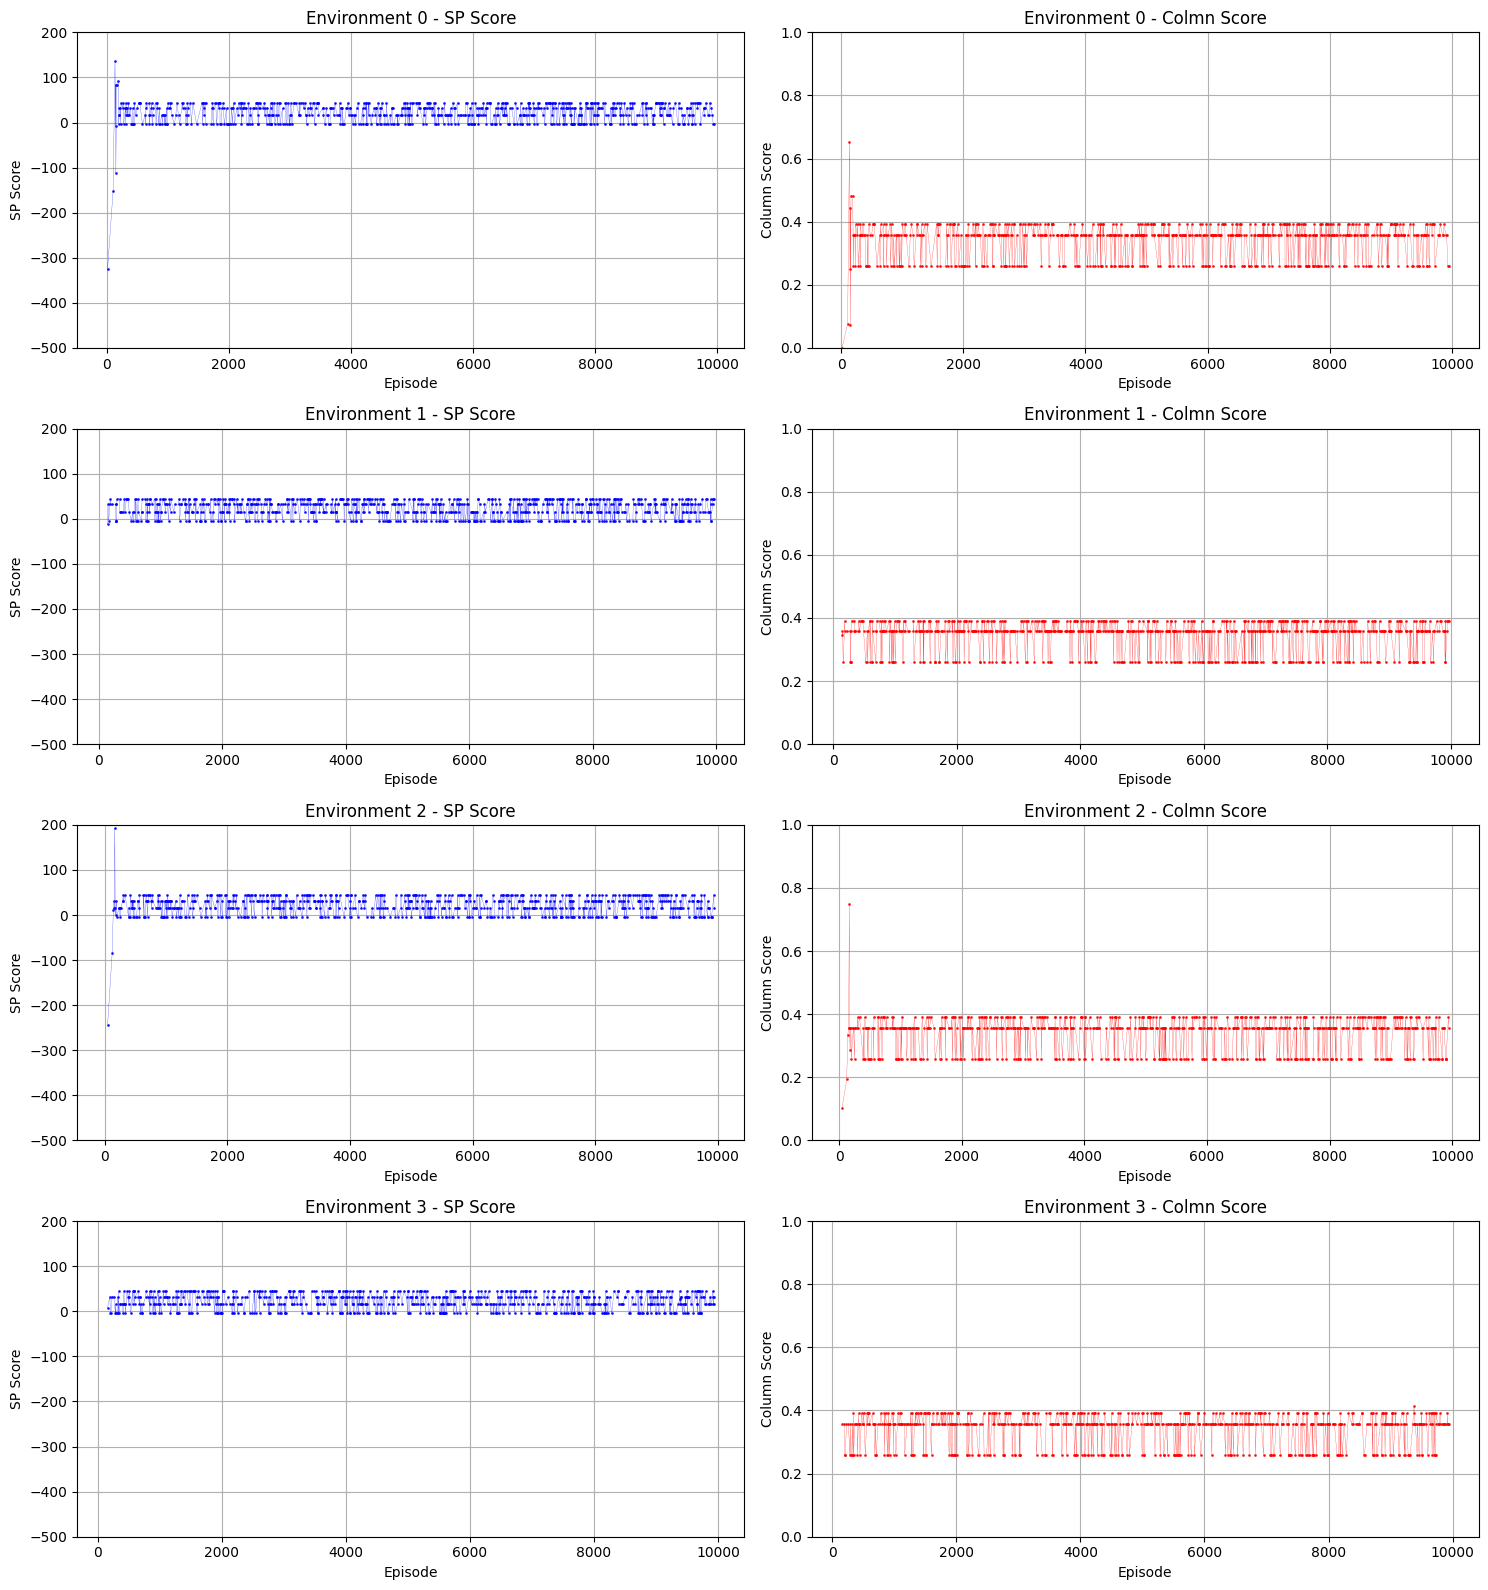

In [211]:
import matplotlib.pyplot as plt

episodes_dicts = msa_vec_env.get_attr('episodes_dict')

fig, axes = plt.subplots(n_envs, 2, figsize=(15, 4*n_envs))
if n_envs == 1:
    axes = axes.reshape(1, -1)

for env_idx, episodes_dict in enumerate(episodes_dicts):
    if len(episodes_dict) == 0:
        continue
    axes[env_idx, 0].set_ylim(-500, 200)
    axes[env_idx, 1].set_ylim(0, 1)
    episodes = list(episodes_dict.keys())
    total_rewards = [episodes_dict[ep]["total_reward"] for ep in episodes]
    aligned_vals = [episodes_dict[ep]["aligned_val"] for ep in episodes]
    
    axes[env_idx, 0].plot(episodes, total_rewards, 'b-', marker='o', markersize=1, linewidth=0.2, alpha=0.8)
    axes[env_idx, 0].set_title(f'Environment {env_idx} - SP Score')
    axes[env_idx, 0].set_xlabel('Episode')
    axes[env_idx, 0].set_ylabel('SP Score')
    axes[env_idx, 0].grid(True)
    
    axes[env_idx, 1].plot(episodes, aligned_vals, 'r-', marker='o', markersize=1, linewidth=0.2, alpha=0.8)
    axes[env_idx, 1].set_title(f'Environment {env_idx} - Colmn Score')
    axes[env_idx, 1].set_xlabel('Episode')
    axes[env_idx, 1].set_ylabel('Column Score')
    axes[env_idx, 1].grid(True)

plt.tight_layout()
plt.show()

In [212]:
class DPA_MSA_ENV_SB3_eval(gym.Env):
    nucleotides_map = {'A': 1, 'T': 2, 'C': 3, 'G': 4, 'a': 1, 't': 2, 'c': 3, 'g': 4, '-': 5}
    
    def __init__(self, data, max_len, match_reward = 4, mismatch_penalty = -4, gap_penalty = -4):
        super().__init__()
        self.episodes_dict = {}
        self.step_count = 0
        self.match_reward = match_reward
        self.mismatch_penalty = mismatch_penalty
        self.gap_penalty = gap_penalty
        self.data = []
        self.max_len = 0
        self.total_reward = 0
        nucleotides_map = {'A': 1, 'T': 2, 'C': 3, 'G': 4, 'a': 1, 't': 2, 'c': 3, 'g': 4, '-': 5}
        self.ep_count = 0
        self.max_len = max_len
        self.data = [[nucleotides_map[data[i][j]] for j in range(len(data[i]))] for i in range(len(data))]
        self.not_aligned = copy.deepcopy(self.data)
        self.row = len(self.data)
        self.action_number = 2 ** (self.row) - 2
        self.max_reward = self.row * (self.row - 1) / 2 * self.match_reward
        self.min_reward = self.row * (self.row - 1) / 2 * min(self.mismatch_penalty, self.gap_penalty)
        self.action_space = spaces.Discrete(self.action_number)
        self.reward_range = (self.min_reward, self.max_reward)
        self.observation_space = spaces.Box(low=0, high=5, shape=(self.row * (self.max_len),), dtype=np.uint8)

    def __get_obs(self):
        state = []
        for i in range(self.row):
            state.extend((
                self.not_aligned[i][j] if j < len(
                    self.not_aligned[i]) else 5) 
                    for j in range(len(self.not_aligned[i])))

        state.extend([0 for _ in range(self.row * (self.max_len) - len(state))])
        return np.array(state, dtype=np.uint8)

    def __calc_reward(self):
        score = 0
        tail = len(self.aligned[0]) - 1
        for j in range(self.row):
            for k in range(j + 1, self.row):
                if self.aligned[j][tail] == 5 or self.aligned[k][tail] == 5:
                    score += self.gap_penalty
                elif self.aligned[j][tail] == self.aligned[k][tail]:
                    score += self.match_reward
                elif self.aligned[j][tail] != self.aligned[k][tail]:
                    score += self.mismatch_penalty

        return score

    def calc_col_score_aligned(self):
        score = 0

        for i in range(len(self.aligned[0])):
            n = self.aligned[0][i]
            flag = True
            for j in range(1, self.row):
                if n != self.aligned[j][i]:
                    flag = False
                    break
            if flag:
                score += 1

        return score/len(self.aligned[0])
    
    def step(self, action):
        self.step_count += 1
        for bit in range(self.row):
            if 0 == (action >> bit) & 0x1 and 0 == len(self.not_aligned[bit]):
                self.total_reward += self.min_reward
                self.ep_count += 1
                return self.__get_obs(), self.min_reward, False, True, {}

        total_len = 0
        for bit in range(self.row):
            if 0 == (action >> bit) & 0x1:
                self.aligned[bit].append(self.not_aligned[bit][0])
                self.not_aligned[bit].pop(0)
            else:
                self.aligned[bit].append(5)
            total_len += len(self.not_aligned[bit])
        self.total_reward += self.__calc_reward()
        if total_len > 0:
            return self.__get_obs(), self.__calc_reward(), False, False, {}
        else:
            self.ep_count += 1
            self.episodes_dict[self.ep_count] = {"aligned_val": self.calc_col_score_aligned(), "total_reward": self.total_reward}
            return self.__get_obs(), self.__calc_reward(), True, False, {}

    def reset(self, seed=24, options=None):
        if self.step_count != 0:
            self.total_reward = 0
        self.step_count = 0
        self.done = False
        self.aligned = [[] for _ in range(self.row)]
        self.not_aligned = copy.deepcopy(self.data)
        return self.__get_obs(), {}


In [ ]:
sp_scores = []
column_scores = []
from stable_baselines3.common.evaluation import evaluate_policy
dataset = dataset3
eval_count = 1000
sample_debt = 0
for index, name in enumerate(dataset.datasets[0:len(dataset.datasets)]):
    seqs = getattr(dataset, name)
    for i in range(eval_count):
        env = DPA_MSA_ENV_SB3_eval(data=seqs, max_len = model.env.get_attr('max_len')[0], match_reward=4, mismatch_penalty=-4, gap_penalty=-4)
        evaluate_policy(model, env, n_eval_episodes=1)
        if len(env.episodes_dict) == 0:
            sample_debt += 1
            break
        
        sample_debt -= 1
        sp_scores.append(env.episodes_dict[1]["total_reward"])
        column_scores.append(env.episodes_dict[1]["aligned_val"])


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


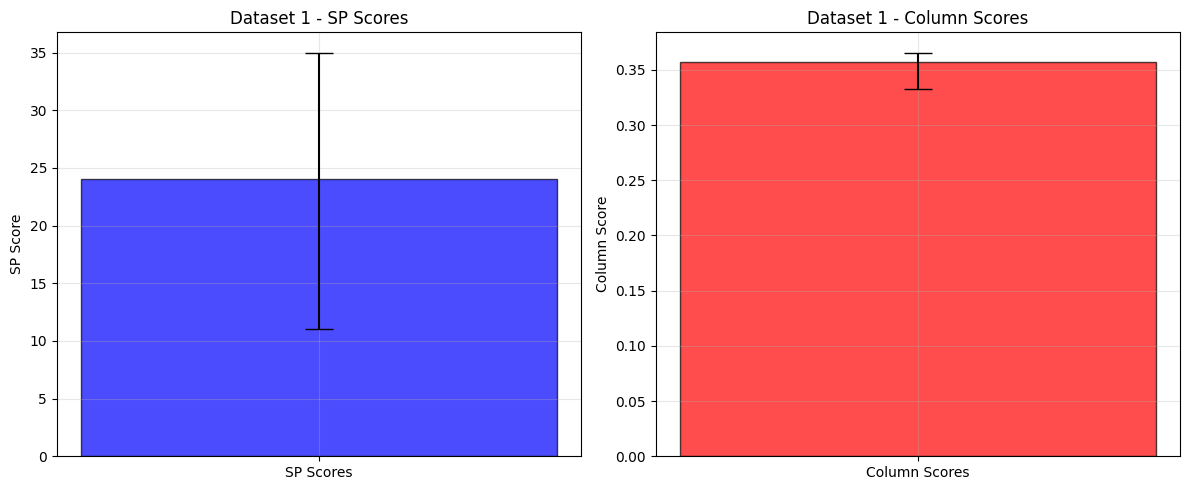

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sp_q1, sp_median, sp_q3 = np.percentile(sp_scores, [25, 50, 75])
col_q1, col_median, col_q3 = np.percentile(column_scores, [25, 50, 75])

sp_bars = ax1.bar(['SP Scores'], [sp_median], 
                  yerr=[[sp_median - sp_q1], [sp_q3 - sp_median]], 
                  capsize=10, 
                  alpha=0.7, 
                  color='blue',
                  edgecolor='black')

ax1.set_ylabel('SP Score')
ax1.set_title('Dataset 1 - SP Scores')
ax1.grid(True, alpha=0.3)

col_bars = ax2.bar(['Column Scores'], [col_median], 
                   yerr=[[col_median - col_q1], [col_q3 - col_median]], 
                   capsize=10, 
                   alpha=0.7, 
                   color='red',
                   edgecolor='black')

ax2.set_ylabel('Column Score')
ax2.set_title('Dataset 1 - Column Scores')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()